In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

In [2]:
# Load and preprocess the data
data = pd.read_csv("../data/task_offloading_dataset.csv")

# Encode target variable
label_encoder = LabelEncoder()
data['Offloading_Decision'] = label_encoder.fit_transform(data['Offloading_Decision'])

# Separate features and target variable
X = data.drop(columns=['Offloading_Decision'])
y = data['Offloading_Decision']

In [3]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [4]:
# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate the original model
train_accuracy = accuracy_score(y_train, clf.predict(X_train))
test_accuracy = accuracy_score(y_test, clf.predict(X_test))
print(f"Original Model - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
# Save the original model
with open("../models/Decision_Trees/Decision_Trees_original.pkl", "wb") as f:
    pickle.dump(clf, f)


Original Model - Train Accuracy: 1.0000, Test Accuracy: 0.9984


In [5]:
# Perform pruning by setting the complexity parameter (ccp_alpha)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train and evaluate pruned models for different values of ccp_alpha
train_accuracies = []
test_accuracies = []
for ccp_alpha in ccp_alphas:
    clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf_pruned.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf_pruned.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf_pruned.predict(X_test)))


In [6]:
# Find the best ccp_alpha that maximizes test accuracy
best_ccp_alpha = ccp_alphas[np.argmax(test_accuracies)]
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
clf_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(5.837504053085202e-06),
                       random_state=42)

In [7]:
# Evaluate the pruned model
train_accuracy_pruned = accuracy_score(y_train, clf_pruned.predict(X_train))
test_accuracy_pruned = accuracy_score(y_test, clf_pruned.predict(X_test))
print(f"Pruned Model - Train Accuracy: {train_accuracy_pruned:.4f}, Test Accuracy: {test_accuracy_pruned:.4f}")

# Save the pruned model
with open("../models/Decision_Trees/Decision_Trees_pruned.pkl", "wb") as f:
    pickle.dump(clf_pruned, f)

Pruned Model - Train Accuracy: 0.9999, Test Accuracy: 0.9985


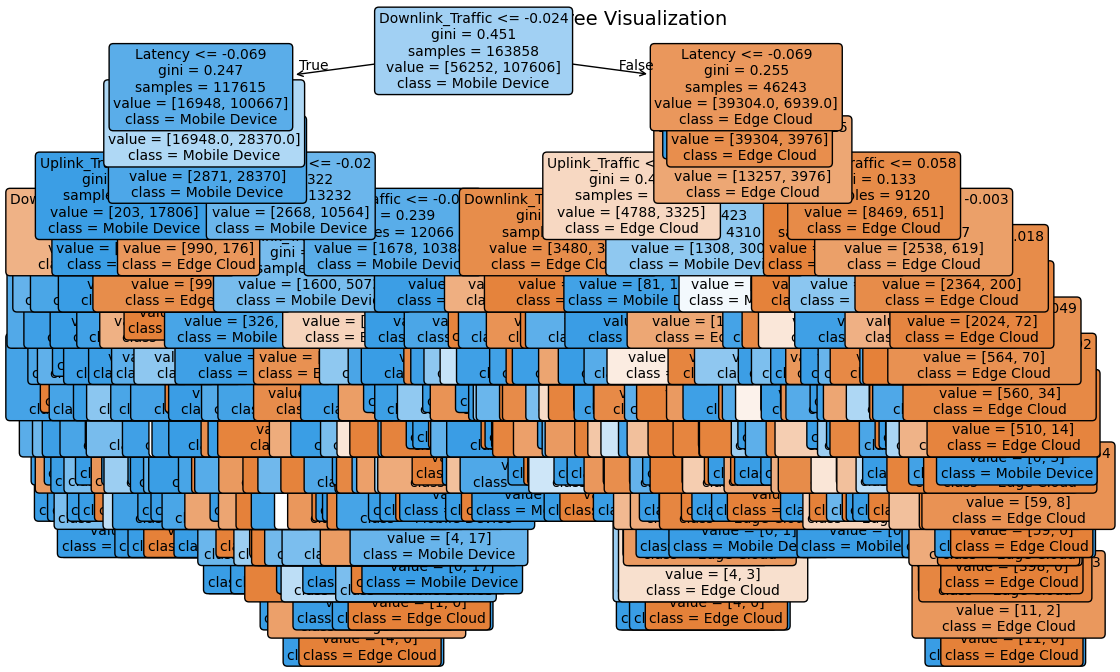

|--- Downlink_Traffic <= -0.02
|   |--- Latency <= -0.07
|   |   |--- class: 1
|   |--- Latency >  -0.07
|   |   |--- Duration <= -0.07
|   |   |   |--- class: 0
|   |   |--- Duration >  -0.07
|   |   |   |--- Downlink_Traffic <= -0.03
|   |   |   |   |--- Uplink_Traffic <= -0.02
|   |   |   |   |   |--- Downlink_Traffic <= -0.03
|   |   |   |   |   |   |--- Uplink_Traffic <= -0.02
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Uplink_Traffic >  -0.02
|   |   |   |   |   |   |   |--- Cell_Identity(CI) <= -1.52
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Cell_Identity(CI) >  -1.52
|   |   |   |   |   |   |   |   |--- Duration <= 3.96
|   |   |   |   |   |   |   |   |   |--- Downlink_Traffic <= -0.03
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- Downlink_Traffic >  -0.03
|   |   |   |   |   |   |   |   |   |   |--- Uplink_Traffic <= -0.02
|   |   |   |   |   |   |   |   |   |   |  

In [8]:
# Visualize the pruned tree
plt.figure(figsize=(12, 8))
plot_tree(clf_pruned, feature_names=X.columns, class_names=label_encoder.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Pruned Decision Tree Visualization", fontsize=14)
plt.show()

# Export the pruned Decision Tree rules to text
tree_rules_pruned = export_text(clf_pruned, feature_names=list(X.columns))
print(tree_rules_pruned)

# Get the file size of the original and pruned models
original_size = os.path.getsize("../models/Decision_Trees/Decision_Trees_original.pkl")
pruned_size = os.path.getsize("../models/Decision_Trees/Decision_Trees_pruned.pkl")
print(f"Size of original model: {original_size / 1024:.2f} KB")
print(f"Size of pruned model: {pruned_size / 1024:.2f} KB")